# Nama : Ahmad mufli ramadhan
# Capstone Team ID =  A25-CS346
# ID use case = DC-01

In [ ]:
!pip install faster-whisper
!pip install -U "pyannote.audio>=4.0.1"


In [32]:
import torch
import os
import soundfile as sf
import warnings
import numpy as np
import json
import re
import glob
from jiwer import wer, cer, Compose, ToLowerCase, ToUpperCase, RemovePunctuation, RemoveMultipleSpaces, Strip
from dotenv import load_dotenv
from pyannote.audio import Pipeline
from faster_whisper import WhisperModel

warnings.filterwarnings("ignore")

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [42]:
load_dotenv()

MODEL_SIZE = 'medium.en'
DATA_PATH = '../data/video/'
AUDIO_PATH = '../data/audio/'
RESULT_PATH = '../result/'
VIDEO_NAME = 'tes.mp4'
TEST_PATH = '../data/openlsr'
OUT_WAV = f"{AUDIO_PATH}{VIDEO_NAME.replace('.mp4', '.wav')}"
HG_TOKEN = os.getenv("HG_TOKEN")

# Extract Audio from video, then save it to local (Optional)

#### please install ffmpeg into your computer, before running it

In [ ]:
audio_out_dir = AUDIO_PATH + (VIDEO_NAME.replace('.mp4', ''))
vid = DATA_PATH + VIDEO_NAME

cmd = f"ffmpeg -i {vid} -vn -ac 1 -ar 16000 -acodec pcm_s16le {OUT_WAV}"
os.system(cmd)

# Voice activity detection model

In [4]:
vad_model, vad_utils = torch.hub.load(
    repo_or_dir='snakers4/silero-vad', model='silero_vad'
)
(get_speech_timestamps, _, read_audio, _, _) = vad_utils


Using cache found in C:\Users\MufliDevs/.cache\torch\hub\snakers4_silero-vad_master


In [11]:
def convert_to_sec(start_sec, end_sec, sr):
  res_start_sec = start_sec / sr
  res_end_sec = end_sec / sr
  return res_start_sec, res_end_sec

def merge_vad_segments(vad_segments, merge_gap=0.2, min_len=0.25):
    if not vad_segments:
        return []

    vad_segments = sorted(vad_segments, key=lambda x: x['start'])
    merged = []
    cur = vad_segments[0].copy()

    for seg in vad_segments[1:]:
        gap = seg['start'] - cur['end']
        if gap <= merge_gap:
            cur['end'] = max(cur['end'], seg['end'])
        else:
            if (cur['end'] - cur['start']) >= min_len:
                merged.append(cur)
            cur = seg.copy()

    if (cur['end'] - cur['start']) >= min_len:
        merged.append(cur)

    return merged

In [12]:
def get_vad_time_stamps(wav, model, sampling_rate=16000, min_speech=250, min_silence=200):
  vad_stamps = get_speech_timestamps(
    wav,
    model,
    sampling_rate=sampling_rate,
    min_speech_duration_ms=min_speech,
    min_silence_duration_ms=min_silence
  )
  for i in range(len(vad_stamps)):
    vad_stamps[i]['start'], vad_stamps[i]['end'] = convert_to_sec(vad_stamps[i]['start'], vad_stamps[i]['end'],16000)

  vad_stamps = merge_vad_segments(vad_stamps)
  return vad_stamps

In [13]:
wav = read_audio(OUT_WAV)
vad_time_stamps = get_vad_time_stamps(wav, vad_model,min_speech=0,min_silence=0)

In [14]:
vad_time_stamps

[{'start': 1.09, 'end': 10.11},
 {'start': 10.37, 'end': 34.11},
 {'start': 34.466, 'end': 52.382},
 {'start': 53.346, 'end': 66.654},
 {'start': 67.394, 'end': 76.414},
 {'start': 76.802, 'end': 86.622},
 {'start': 86.978, 'end': 95.742},
 {'start': 96.098, 'end': 110.942}]

# Load whisper and pyannote

In [27]:
pyannote_pipeline = Pipeline.from_pretrained(
    'pyannote/speaker-diarization-community-1',
    token=HG_TOKEN
)

whisper_model = WhisperModel(MODEL_SIZE, device="cuda", compute_type="float16")

audio, sr = sf.read(OUT_WAV, dtype="float32")

In [36]:
def diarization(vad_time_stamps, audio, sample_rate):
    all_diar = []

    for seg in vad_time_stamps:
        start = seg['start']
        end = seg['end']

        start_samp = int(start * sample_rate)
        end_samp = int(end * sample_rate)

        chunk = audio[start_samp:end_samp].astype('float32')
        chunk = np.ascontiguousarray(chunk)

        wav_tensor = torch.from_numpy(chunk).unsqueeze(0)

        with torch.no_grad():
            diar = pyannote_pipeline({"waveform": wav_tensor, "sample_rate": sample_rate})

        for turn, speaker in diar.speaker_diarization:
            g_start = start + turn.start
            g_end = start + turn.end
            all_diar.append({"start": g_start, "end": g_end, "speaker": speaker})

    return all_diar

def transcribe_from_diarization(all_diar, model, audio, sample_rate):
    result = []

    for seg in all_diar:
        if seg['end'] - seg['start'] < 0.4:
            continue
        
        start_samp = int(seg['start'] * sample_rate)
        end_samp = int(seg['end'] * sample_rate)

        chunk = audio[start_samp:end_samp].astype('float32')
        segs, info = model.transcribe(chunk, beam_size=5)
        text = " ".join([segment.text for segment in segs]).strip()

        result.append({
        "start": seg['start'],
        "end": seg['end'],
        "speaker": seg['speaker'],
        "text": text
        })
    
    return result

def process_file(audio, vad_model, sampling_rate, asr_model):
    vad_sec = get_vad_time_stamps(audio, vad_model, sampling_rate)
    all_diar = diarization(vad_sec, audio, sr)
    segs = transcribe_from_diarization(all_diar, asr_model, audio, sr)
    hyp_full = ' '.join(s['text'] for s in segs).strip()
    return hyp_full, segs

In [37]:
hyp_full, segs = process_file(audio=audio, vad_model=vad_model, sampling_rate=sr, asr_model=whisper_model)

In [40]:
hyp_full

"Hi, my name is Janelle Davis.  I'm currently a student in my second year  at Coventry University.  I'm studying economics and I really enjoy it. Prior to this, I took a gap year from sixth form to work in an apprenticeship  through a charity called NCS to Challenge from the years 2015 to 2016. My role as business administrator for a recruitment agency meant that I was working with 10 to 12 other people. and as it was such a small environment it meant that I was able to communicate  easily with others as well as asking for help when I best needed it. At the same time, I also had a part-time job in the retail sector. This meant I was working in a flagship store  through a company called Primark. with 1,500 other colleagues. This meant that I was very likely to bump into someone that I wouldn't necessarily bump into every day. Working in these two conflicting environments, so one being small and one being very large,  this meant that I was able to develop my adaptability skills as well a

In [39]:
segs

[{'start': 1.12096875,
  'end': 9.98034375,
  'speaker': 'SPEAKER_00',
  'text': "Hi, my name is Janelle Davis.  I'm currently a student in my second year  at Coventry University.  I'm studying economics and I really enjoy it."},
 {'start': 10.400968749999999,
  'end': 20.25596875,
  'speaker': 'SPEAKER_00',
  'text': 'Prior to this, I took a gap year from sixth form to work in an apprenticeship  through a charity called NCS to Challenge from the years 2015 to 2016.'},
 {'start': 20.35721875,
  'end': 26.90471875,
  'speaker': 'SPEAKER_00',
  'text': 'My role as business administrator for a recruitment agency meant that I was working with 10 to 12 other people.'},
 {'start': 27.073468749999996,
  'end': 34.29596875,
  'speaker': 'SPEAKER_00',
  'text': 'and as it was such a small environment it meant that I was able to communicate  easily with others as well as asking for help when I best needed it.'},
 {'start': 34.83446875,
  'end': 39.37384375,
  'speaker': 'SPEAKER_00',
  'text': '

#### save result to json

In [ ]:
with open(f"{RESULT_PATH}{VIDEO_NAME.replace('.mp4', '')}_transcript.json", "w") as f:
    json.dump(segs, f, indent=4)
    f.close()

# Validation with CER and WER using OpenLSR dataset

#### function for reading files from the dataset

In [54]:
def normalize_text(s: str):
    s = s.lower()
    s = re.sub(r"[^\w\s]", "", s)      
    s = re.sub(r"\s+", " ", s).strip()  
    return s

def read_librispeech_reference(flac_path: str):
    utt_id = os.path.splitext(os.path.basename(flac_path))[0]
    chapter_dir = os.path.dirname(flac_path)

    spk, chap, _ = utt_id.split('-')
    trans_path = os.path.join(chapter_dir, f"{spk}-{chap}.trans.txt")

    if not os.path.exists(trans_path):
        candidates = glob.glob(os.path.join(chapter_dir, '*.trans.txt'))

        if not candidates:
            raise FileNotFoundError(f"trans.txt tidak ditemukan {flac_path}")
        trans_path = candidates[0]
    
    with open(trans_path, 'r') as f:
        for line in f:
            key, txt = line.strip().split(" ", 1)
            if key == utt_id:
                txt = txt.strip()

                if txt.startswith("(") and ") =" in txt:
                    right = txt.split(") = ", 1)[-1]
                    return right
                return txt
    
    raise ValueError(f"Tidak ada baris referensi utk {utt_id} di {trans_path}")


def evaluate_librispeech_subset(base_dir, vad_model, asr_model):
    flacs = glob.glob(os.path.join(base_dir, "**", "*.flac"), recursive=True)
    details = []
    total_w, total_c = 0.0, 0.0

    for i, fp in enumerate(flacs, 1):
        print(f"[{i}/{len(flacs)}] {fp}")
        ref = read_librispeech_reference(fp)
        audio, sr = sf.read(fp, dtype="float32")
        hyp, segs = process_file(audio,vad_model,sr,asr_model)

        ref_n = normalize_text(ref)
        hyp_n = normalize_text(hyp)
        w = wer(ref_n, hyp_n)
        c = cer(ref_n, hyp_n)

        details.append({
            'file': fp,
            'ref': ref,
            'hyp': hyp,
            'wer': w,
            'cer': c,
            'segments': segs
        })

        total_w += w
        total_c += c
    
    avg_wer = total_w / max(1, len(details))
    avg_cer = total_c / max(1, len(details))

    result = {
        'Average WER': avg_wer,
        'Average CER': avg_cer,
        'Details': details
    }

    return result

In [56]:
final_result = evaluate_librispeech_subset(TEST_PATH, vad_model, whisper_model)

[1/2620] ../data/openlsr\1089\134686\1089-134686-0000.flac
[2/2620] ../data/openlsr\1089\134686\1089-134686-0001.flac
[3/2620] ../data/openlsr\1089\134686\1089-134686-0002.flac
[4/2620] ../data/openlsr\1089\134686\1089-134686-0003.flac
[5/2620] ../data/openlsr\1089\134686\1089-134686-0004.flac
[6/2620] ../data/openlsr\1089\134686\1089-134686-0005.flac
[7/2620] ../data/openlsr\1089\134686\1089-134686-0006.flac
[8/2620] ../data/openlsr\1089\134686\1089-134686-0007.flac
[9/2620] ../data/openlsr\1089\134686\1089-134686-0008.flac
[10/2620] ../data/openlsr\1089\134686\1089-134686-0009.flac
[11/2620] ../data/openlsr\1089\134686\1089-134686-0010.flac
[12/2620] ../data/openlsr\1089\134686\1089-134686-0011.flac
[13/2620] ../data/openlsr\1089\134686\1089-134686-0012.flac
[14/2620] ../data/openlsr\1089\134686\1089-134686-0013.flac
[15/2620] ../data/openlsr\1089\134686\1089-134686-0014.flac
[16/2620] ../data/openlsr\1089\134686\1089-134686-0015.flac
[17/2620] ../data/openlsr\1089\134686\1089-134686

In [58]:
with open(f"{RESULT_PATH}librispeech_evaluation.json", "w") as f:
    json.dump(final_result, f, indent=4)
    f.close()

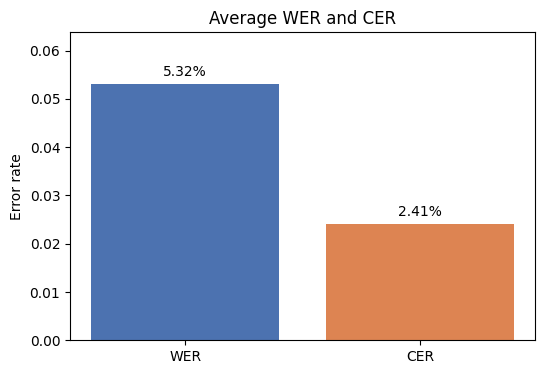

In [59]:
import matplotlib.pyplot as plt

wer = final_result.get('Average WER', final_result.get('average wer', None))
cer = final_result.get('Average CER', final_result.get('average cer', None))

if wer is None or cer is None:
    raise KeyError("Could not find Average WER/CER in final_result. Keys found: " + ", ".join(final_result.keys()))

labels = ['WER', 'CER']
values = [wer, cer]

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(labels, values, color=['#4C72B0', '#DD8452'])
ax.set_ylabel('Error rate')
ax.set_title('Average WER and CER')

for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width() / 2, v + max(values)*0.02, f"{v:.2%}", ha='center', va='bottom')

ax.set_ylim(0, max(values) * 1.2)
plt.show()